In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.6f}'.format

matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 


df = pd.read_csv("participants_info.csv", delimiter=",")
df_mod = pd.read_csv("modalities_info.csv", delimiter=",")[["participant_id", "session", "anat", "fmri", "dwi"]].drop_duplicates(subset="participant_id", keep="first")
df = pd.merge(df, df_mod, on = "participant_id", how="left")
# Assume df is your dataframe

# 2. Map group codes to labels
group_map = {
    0: "HC",
    0.1: "HC Sibling",
    1: "SCHZ",
    1.1: "SCHZ Sibling",
    2: "BD",
    3: "FEP",
    4: "MDD",
    5: "CHR",
    6: "ADHD",
    7: "PTSD",
    8: "GAD",
    9: "SAD",
    10: "SUD",
    11: "OCD",
    12: "SEAD",
    13: "ASD",
    14: "CPS",
    15: "Stroke",
    16: "BPD",
    17: "ARMS",
    18: "AN",
    19: "WR",
    20: "AUD",
    21: "Panic Episode",
    22: "Agoraphobia"
}

# Keep only one row per participant
df_unique = df.copy()

# Split ONLY entries that contain ';'
df_unique["group_split"] = df_unique["group"].astype(str).str.split(";")

# Expand multiple-group participants into multiple rows
df_exploded = df_unique.explode("group_split")

# Convert to numeric (preserves 0.1, 1.1, etc.)
df_exploded["group_split"] = pd.to_numeric(
    df_exploded["group_split"].str.strip(),
    errors="coerce"
)

# Map codes to labels
df_exploded["group_label"] = df_exploded["group_split"].map(group_map)

# Count participants in each group
counts = df_exploded["group_label"].value_counts()

# Percentage relative to total unique participants
n_participants = df_unique["participant_id"].nunique()

percentages = counts / n_participants * 100

result = pd.DataFrame({
    "count": counts,
    "percentage": percentages
}).sort_values("count", ascending=False)

print(result)

               count  percentage
group_label                     
HC              4878   57.213230
SCHZ            1147   13.452967
MDD              786    9.218860
ADHD             322    3.776683
GAD              246    2.885292
BD               243    2.850106
ASD              127    1.489561
SUD              125    1.466104
HC Sibling        87    1.020408
CHR               81    0.950035
SCHZ Sibling      79    0.926578
CPS               67    0.785832
WR                58    0.680272
AN                58    0.680272
ARMS              52    0.609899
PTSD              49    0.574713
Panic Episode     47    0.551255
BPD               46    0.539526
FEP               41    0.480882
AUD               41    0.480882
SAD               31    0.363594
OCD               27    0.316678
Agoraphobia       18    0.211119
Stroke            10    0.117288
SEAD               1    0.011729


In [23]:
total_participants = df_unique["participant_id"].nunique()

print(f"Total participants: {total_participants}")

Total participants: 8526


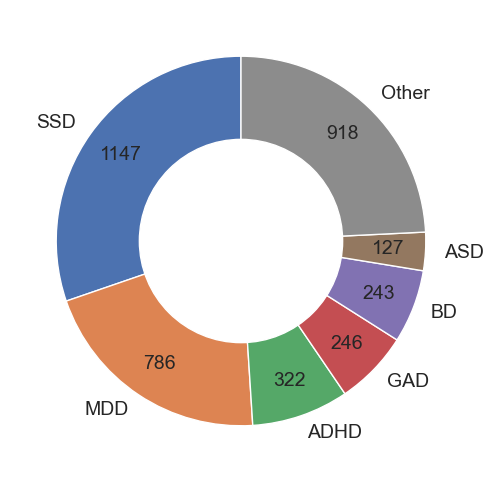

In [14]:
sns.set(style="white")

# Remove HC from exploded dataframe
df_no_hc = df_exploded[df_exploded["group_label"] != "HC"].copy()

# --- Rename labels ---
rename_map = {
    "SCHZ": "SSD",
}

df_no_hc["group_label"] = df_no_hc["group_label"].replace(rename_map)

# --- Counts ---
diag_counts = df_no_hc["group_label"].value_counts().sort_values(ascending=False)

# --- Top 6 + Other ---
top_n = 6
top_counts = diag_counts.iloc[:top_n]
other_count = diag_counts.iloc[top_n:].sum()

diag_counts_reduced = top_counts.copy()
if other_count > 0:
    diag_counts_reduced.loc["Other"] = other_count

# --- Plot ---
plt.figure(figsize=(6, 6))

colors = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52",
    "#8172B2",
    "#937860",
    "#8C8C8C",
    "#CCB974",
    "#64B5CD"
]

def autopct_counts(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}"
    return inner

plt.pie(
    diag_counts_reduced,
    labels=diag_counts_reduced.index,
    autopct=autopct_counts(diag_counts_reduced),
    startangle=90,
    colors=colors[:len(diag_counts_reduced)],
    pctdistance=0.8,
    textprops={"fontsize": 14}
)

centre_circle = plt.Circle((0, 0), 0.55, fc="white")
plt.gca().add_artist(centre_circle)

plt.savefig("figs3.1.pdf", format="pdf", bbox_inches="tight")
plt.show()

sex_clean
Male      1879
Female    1503
Name: count, dtype: int64


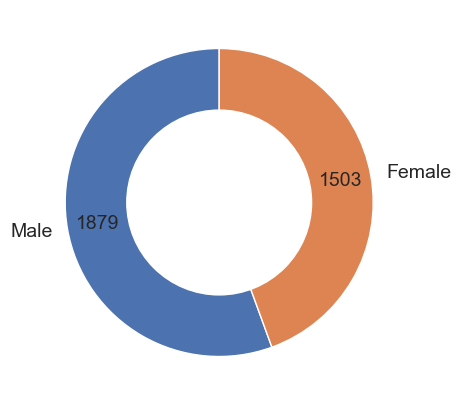

In [18]:
sns.set(style="white")

# -----------------------------
# KEEP ONLY PATIENT GROUP ROWS
# -----------------------------
df_patients_long = df_exploded[
    (df_exploded["group_label"].notna()) &
    (df_exploded["group_label"] != "HC")
].copy()

# -----------------------------
# ONE ROW PER PATIENT FOR SEX
# -----------------------------
df_patients = (
    df_patients_long
    .drop_duplicates(subset="participant_id", keep="first")
    .copy()
)

# -----------------------------
# CLEAN + MAP SEX
# -----------------------------
df_patients["sex_clean"] = pd.to_numeric(df_patients["sex"], errors="coerce")

sex_map = {
    0: "Female",
    1: "Male"
}

sex_series = df_patients["sex_clean"].map(sex_map).dropna()

sex_counts = sex_series.value_counts()

print(sex_counts)

# Stop if empty
if sex_counts.empty:
    print("No valid sex values found. Check df_patients['sex'].unique():")
    print(df_patients["sex"].unique())
else:
    plt.figure(figsize=(5, 5))

    colors = ["#4C72B0", "#DD8452"]

    def autopct_counts(values):
        def inner(pct):
            total = sum(values)
            count = int(round(pct * total / 100.0))
            return f"{count}"
        return inner

    plt.pie(
        sex_counts,
        labels=sex_counts.index,
        autopct=autopct_counts(sex_counts),
        startangle=90,
        colors=colors[:len(sex_counts)],
        pctdistance=0.8,
        wedgeprops={"edgecolor": "white"},
        textprops={"fontsize": 14}
    )

    centre_circle = plt.Circle((0, 0), 0.6, fc="white")
    plt.gca().add_artist(centre_circle)

    plt.savefig("figs3.2.pdf", format="pdf", bbox_inches="tight")
    plt.show()

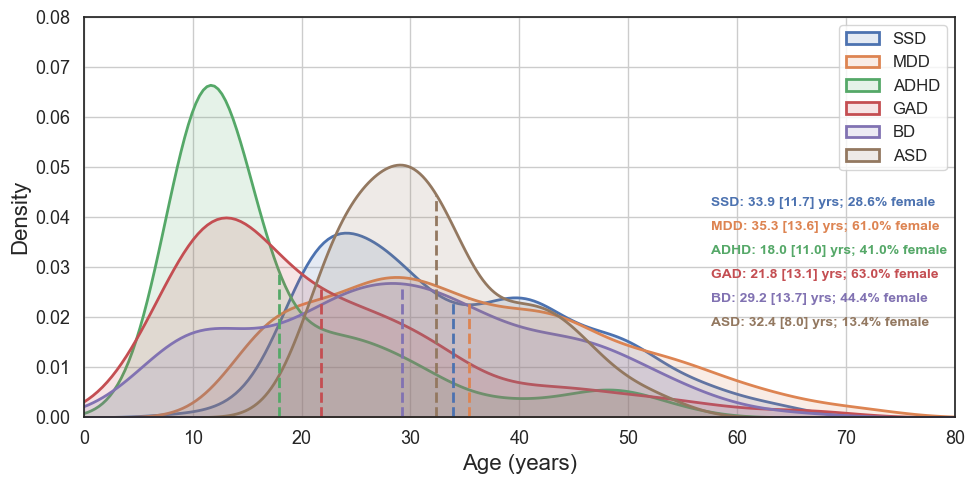

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

sns.set(style="white")

# -----------------------------
# REMOVE HC
# -----------------------------
df_no_hc = df_exploded[
    (df_exploded["group_label"].notna()) &
    (df_exploded["group_label"] != "HC")
].copy()

# -----------------------------
# RENAME LABELS
# -----------------------------
df_no_hc["group_label"] = df_no_hc["group_label"].replace({"SCHZ": "SSD"})

# Avoid duplicate participant within same group
df_no_hc = df_no_hc.drop_duplicates(
    subset=["participant_id", "group_label"],
    keep="first"
)

# -----------------------------
# TOP 6 GROUPS
# -----------------------------
top_groups = df_no_hc["group_label"].value_counts().head(6).index
df_top = df_no_hc[df_no_hc["group_label"].isin(top_groups)].copy()

# -----------------------------
# SEX MAP
# -----------------------------
sex_map = {0: "Female", 1: "Male"}

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    "#4C72B0", "#DD8452", "#55A868",
    "#C44E52", "#8172B2", "#937860",
]

stats_lines = []
stats_colors = []

for group, color in zip(top_groups, colors):
    subset = df_top[df_top["group_label"] == group].copy()

    ages = pd.to_numeric(subset["age"], errors="coerce").dropna()

    if len(ages) < 2:
        continue

    sns.kdeplot(
        ages,
        fill=True,
        linewidth=2,
        color=color,
        label=group,
        alpha=0.15,
        ax=ax
    )

    mean_age = ages.mean()
    kde = gaussian_kde(ages)
    y_mean = kde(mean_age)[0]

    ax.plot(
        [mean_age, mean_age],
        [0, y_mean],
        color=color,
        linestyle="--",
        linewidth=2
    )

    std_age = ages.std()

    sex_clean = pd.to_numeric(subset["sex"], errors="coerce")
    sex = sex_clean.map(sex_map).dropna()
    sex_pct = sex.value_counts(normalize=True) * 100
    female_pct = sex_pct.get("Female", 0)

    line = (
        f"{group}: "
        f"{mean_age:.1f} [{std_age:.1f}] yrs; "
        f"{female_pct:.1f}% female"
    )

    stats_lines.append(line)
    stats_colors.append(color)

# -----------------------------
# FORMATTING
# -----------------------------
ax.set_xlabel("Age (years)", fontsize=16)
ax.set_ylabel("Density", fontsize=16)

ax.set_xticks(np.arange(0, 81, 10))
ax.set_xlim(0, 80)
ax.set_ylim(0, 0.08)

ax.legend(fontsize=12, loc="upper right")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
ax.grid(True)

# -----------------------------
# COLORED TEXT BOX
# -----------------------------
x_pos = 0.72
y_start = 0.55
line_spacing = 0.06

for i, (line, color) in enumerate(zip(stats_lines, stats_colors)):
    ax.text(
        x_pos,
        y_start - i * line_spacing,
        line,
        transform=ax.transAxes,
        fontsize=10,
        color=color,
        fontweight="bold",
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0)
    )

plt.tight_layout()
plt.savefig("figs3.3.pdf", format="pdf", bbox_inches="tight")
plt.show()

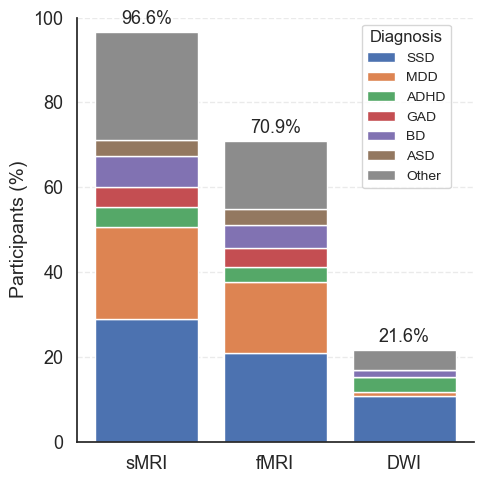

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# USE EXPLODED GROUPS
# -----------------------------
df_patients = df_exploded[
    (df_exploded["group_label"].notna()) &
    (df_exploded["group_label"] != "HC")
].copy()

# Rename
df_patients["group_label"] = df_patients["group_label"].replace({
    "SCHZ": "SSD"
})

# Avoid duplicate participant within same diagnosis
df_patients = df_patients.drop_duplicates(
    subset=["participant_id", "group_label"],
    keep="first"
)

# -----------------------------
# TOP 6 DIAGNOSES
# -----------------------------
top_groups = df_patients["group_label"].value_counts().head(6).index

df_patients["group_reduced"] = df_patients["group_label"].where(
    df_patients["group_label"].isin(top_groups),
    "Other"
)

# -----------------------------
# MODALITIES
# -----------------------------
modalities = ["anat", "fmri", "dwi"]
labels = ["sMRI", "fMRI", "DWI"]

colors_main = [
    "#4C72B0", "#DD8452", "#55A868",
    "#C44E52", "#8172B2", "#937860"
]
color_other = "#8C8C8C"

ordered_groups = list(top_groups) + ["Other"]
colors_all = colors_main + [color_other]

# -----------------------------
# ONE ROW PER PARTICIPANT FOR TOTAL MODALITY %
# -----------------------------
patient_ids = df_patients["participant_id"].unique()
df_patients_unique = df_unique[df_unique["participant_id"].isin(patient_ids)].copy()

# -----------------------------
# COMPUTE STACKED VALUES
# -----------------------------
stack_values = []

for modality in modalities:
    df_mod = df_patients[df_patients[modality] == 1]

    total_pct = pd.to_numeric(
        df_patients_unique[modality],
        errors="coerce"
    ).mean() * 100

    if len(df_mod) == 0:
        stack_values.append([0] * len(ordered_groups))
        continue

    dist = (
        df_mod["group_reduced"]
        .value_counts(normalize=True)
        .reindex(ordered_groups, fill_value=0)
    )

    scaled = dist * total_pct
    stack_values.append(scaled.values)

stack_values = np.array(stack_values)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(5, 5))
plt.grid(axis="y", linestyle="--", alpha=0.4)

bottom = np.zeros(len(modalities))

for i, (group, color) in enumerate(zip(ordered_groups, colors_all)):
    values = stack_values[:, i]

    plt.bar(
        labels,
        values,
        bottom=bottom,
        color=color,
        label=group
    )

    bottom += values

# -----------------------------
# TOTAL % LABELS
# -----------------------------
totals = [
    pd.to_numeric(df_patients_unique[col], errors="coerce").mean() * 100
    for col in modalities
]

for i, total in enumerate(totals):
    plt.text(
        i,
        total + 1,
        f"{total:.1f}%",
        ha="center",
        va="bottom",
        fontsize=13
    )

plt.ylabel("Participants (%)", fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0, 100)

sns.despine()

plt.legend(
    bbox_to_anchor=(0.7, 1),
    loc="upper left",
    fontsize=10,
    title="Diagnosis"
)

plt.tight_layout()
plt.savefig("fig3.4.pdf", format="pdf", bbox_inches="tight")
plt.show()